<a href="https://colab.research.google.com/github/Jawntae/neetcode-submissions/blob/main/Midterm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

In [14]:
data = pd.read_csv('train.csv')
data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [15]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [21]:
dShape = data.shape
dColumns = data.columns
dTypes = data.dtypes
dNull = data.isnull().sum()

print(f'-----Shape: -----\n{dShape}')
print(f'-----Columns: -----\n{dColumns}')
print(f'-----Types: -----\n{dTypes}')
print(f'-----Null: -----\n{dNull}')

-----Shape: -----
(1460, 81)
-----Columns: -----
Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea

In [38]:
df = pd.read_csv('train.csv')
print('head:')
df.head(10)

# Cleaning steps:
print("\nMissing values before cleaning:")
missing_values_count = df.isnull().sum()
missing_values_percentage = (missing_values_count / len(df)) * 100
# Filter to show only columns with missing values
missing_df = pd.DataFrame({
    'Missing Count': missing_values_count,
    'Missing Percentage': missing_values_percentage
}).sort_values(by='Missing Percentage', ascending=False)
print(missing_df[missing_df['Missing Count'] > 0])

head:

Missing values before cleaning:
              Missing Count  Missing Percentage
PoolQC                 1453           99.520548
MiscFeature            1406           96.301370
Alley                  1369           93.767123
Fence                  1179           80.753425
MasVnrType              872           59.726027
FireplaceQu             690           47.260274
LotFrontage             259           17.739726
GarageQual               81            5.547945
GarageFinish             81            5.547945
GarageType               81            5.547945
GarageYrBlt              81            5.547945
GarageCond               81            5.547945
BsmtFinType2             38            2.602740
BsmtExposure             38            2.602740
BsmtCond                 37            2.534247
BsmtQual                 37            2.534247
BsmtFinType1             37            2.534247
MasVnrArea                8            0.547945
Electrical                1            0.068493


In [39]:
# Drop columns with a very high percentage of missing values (e.g., > 80%)
# PoolQC, MiscFeature, Alley, Fence all have > 80% missing
columns_to_drop = missing_df[missing_df['Missing Percentage'] > 80].index.tolist()
df = df.drop(columns=columns_to_drop)
print(f"Dropped columns: {columns_to_drop}")

# Impute categorical columns where NaN means 'None' (absence of feature)
# MasVnrType, FireplaceQu, all Bsmt_ and Garage_ columns fit this description
for col in ['MasVnrType', 'FireplaceQu', 'BsmtQual', 'BsmtCond', 'BsmtExposure',
            'BsmtFinType1', 'BsmtFinType2', 'GarageType', 'GarageFinish',
            'GarageQual', 'GarageCond']:
    if col in df.columns:
        df[col] = df[col].fillna('None')

# Impute numerical columns with the median
for col in ['LotFrontage', 'MasVnrArea', 'GarageYrBlt']:
    if col in df.columns:
        if df[col].dtype in ['float64', 'int64']:
            df[col] = df[col].fillna(df[col].median())

# Impute 'Electrical' (categorical) with the mode as it has only 1 missing value
if 'Electrical' in df.columns:
    df['Electrical'] = df['Electrical'].fillna(df['Electrical'].mode()[0])


print("\nMissing values after cleaning:")
missing_values_count_after = df.isnull().sum()
missing_values_percentage_after = (missing_values_count_after / len(df)) * 100
missing_df_after = pd.DataFrame({
    'Missing Count': missing_values_count_after,
    'Missing Percentage': missing_values_percentage_after
}).sort_values(by='Missing Percentage', ascending=False)
print(missing_df_after[missing_df_after['Missing Count'] > 0])

print("\nDataset info after cleaning:")
df.info()

Dropped columns: ['PoolQC', 'MiscFeature', 'Alley', 'Fence']

Missing values after cleaning:
Empty DataFrame
Columns: [Missing Count, Missing Percentage]
Index: []

Dataset info after cleaning:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 77 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1460 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   LotShape       1460 non-null   object 
 7   LandContour    1460 non-null   object 
 8   Utilities      1460 non-null   object 
 9   LotConfig      1460 non-null   object 
 10  LandSlope      1460 non-null   object 
 11  Neighborhood   1460 non-null   object 
 12  Condition1     1460 non-null   object 
 13  Condition2     1460 non-null   obj

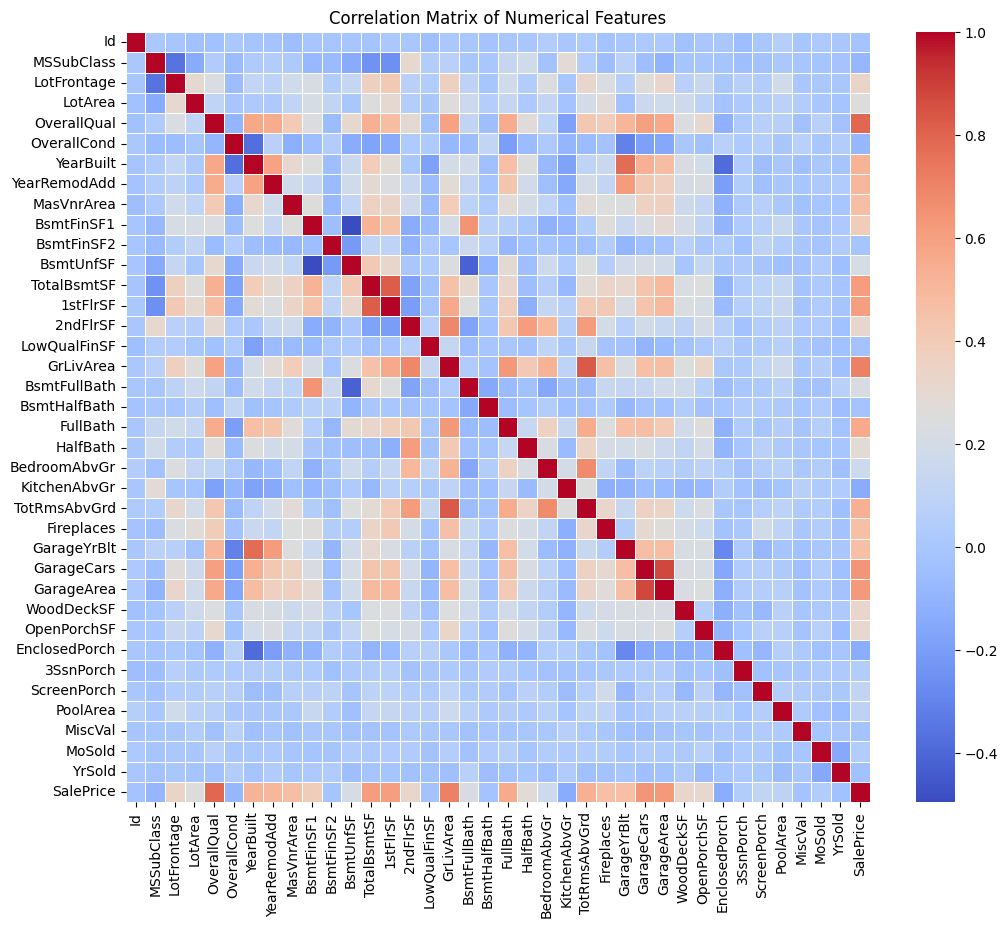


Features correlated with SalePrice (descending order):
 SalePrice        1.000000
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
MasVnrArea       0.472614
Fireplaces       0.466929
GarageYrBlt      0.466754
BsmtFinSF1       0.386420
LotFrontage      0.334771
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
ScreenPorch      0.111447
PoolArea         0.092404
MoSold           0.046432
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
Id              -0.021917
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
Enclose

In [40]:
# correlation matrix to see what features correlate
correlation_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

# Identify features most correlated with SalePrice
sale_price_corr = correlation_matrix['SalePrice'].sort_values(ascending=False)
print("\nFeatures correlated with SalePrice (descending order):\n", sale_price_corr)

In [51]:
# Remove outlier sale prices
Q1 = df['SalePrice'].quantile(0.25)
Q3 = df['SalePrice'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# data is between lower and higher outliers
df = df[(df['SalePrice'] >= lower_bound) & (df['SalePrice'] <= upper_bound)]

print(f'-----Max sale prices------')
print(df['SalePrice'].max())
print(f'-----Min sale prices------')
print(df['SalePrice'].min())

-----Max sale prices------
299800
-----Min sale prices------
34900


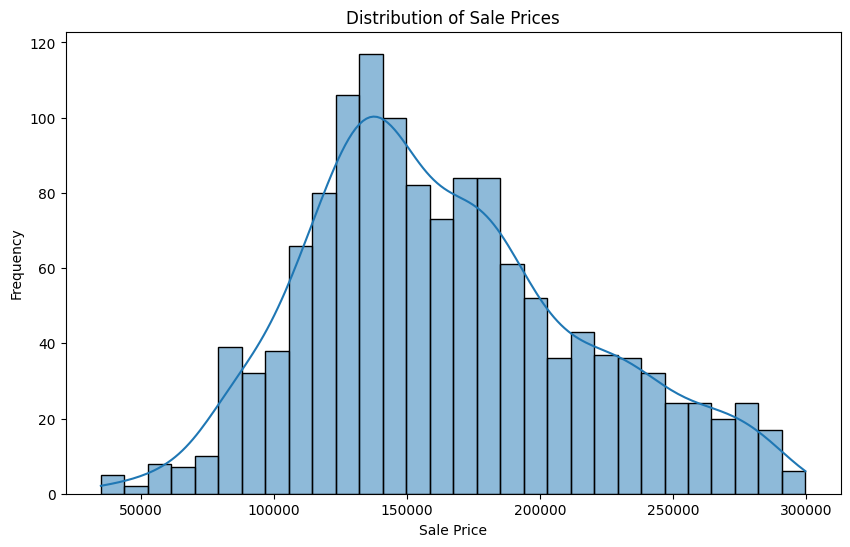

In [56]:
# plot overall prices without outliers
plt.figure(figsize=(10, 6))
sns.histplot(df['SalePrice'], bins=30, kde=True)
plt.title('Distribution of Sale Prices')
plt.xlabel('Sale Price')
plt.ylabel('Frequency')
plt.show()

In [52]:
df.info()
# Feature Engineering:
# created total Sq. footage, Total bath, year since remodel/built,


# 1. Total Square Footage
df['TotalSF'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']

# 2. Total Bathrooms
df['TotalBath'] = df['FullBath'] + (df['HalfBath'] * 0.5) + df['BsmtFullBath'] + (df['BsmtHalfBath'] * 0.5)

# 3. Year since Remodel or Built
df['YearsSinceRemodel'] = df['YrSold'] - df['YearRemodAdd']
df['YearsSinceBuilt'] = df['YrSold'] - df['YearBuilt']

print("\nNew features created: TotalSF, TotalBath, YearsSinceRemodel, YearsSinceBuilt")

# Re-evaluate correlation with SalePrice for new features
print("\nCorrelation of new features with SalePrice:")
print(df[['SalePrice', 'TotalSF', 'TotalBath', 'YearsSinceRemodel', 'YearsSinceBuilt']].corr()['SalePrice'])

<class 'pandas.core.frame.DataFrame'>
Index: 1345 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Id                 1345 non-null   int64  
 1   MSSubClass         1345 non-null   int64  
 2   MSZoning           1345 non-null   object 
 3   LotFrontage        1345 non-null   float64
 4   LotArea            1345 non-null   int64  
 5   Street             1345 non-null   object 
 6   LotShape           1345 non-null   object 
 7   LandContour        1345 non-null   object 
 8   Utilities          1345 non-null   object 
 9   LotConfig          1345 non-null   object 
 10  LandSlope          1345 non-null   object 
 11  Neighborhood       1345 non-null   object 
 12  Condition1         1345 non-null   object 
 13  Condition2         1345 non-null   object 
 14  BldgType           1345 non-null   object 
 15  HouseStyle         1345 non-null   object 
 16  OverallQual        1345 non-n

In [61]:
Features = ['TotalSF', 'TotalBath', 'YearsSinceRemodel', 'YearsSinceBuilt', 'OverallQual']

X_train, X_test, Y_train, Y_test = train_test_split(df[Features], df['SalePrice'], test_size=0.2, random_state=42)

scalar = StandardScaler()
X_train_scaled = scalar.fit_transform(X_train)
X_test_scaled = scalar.transform(X_test)

lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, Y_train)

Y_pred_test = lin_reg.predict(X_test_scaled)
y_pred_train = lin_reg.predict(X_train_scaled)

mse = mean_squared_error(Y_test, Y_pred_test)
mae = mean_absolute_error(Y_test, Y_pred_test)
r2 = r2_score(Y_test, Y_pred_test)

print(f'MSE: {mse}')
print(f'MAE: {mae}')
print(f'R2: {r2}')




MSE: 818234077.6564062
MAE: 19659.665848127333
R2: 0.6858424586378572
